In [47]:
import argparse, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [48]:
def load_accuracy_from_log(method, log_dir, category, win_size, stride_size):
    """Load accuracy labels from JSON logs under one directory."""
    df = pd.DataFrame()
    if not os.path.isdir(log_dir):
        return df

    for acc_file in os.listdir(log_dir):
        if not acc_file.endswith(".json"):
            continue
        acc_path = os.path.join(log_dir, acc_file)
        with open(acc_path, "r") as f:
            json_data = json.load(f)

        # Extract content from OpenAI-style response["choices"][0]["message"]["content"]
        resp = json_data.get("response", {})
        choices = resp.get("choices", [])
        if not choices:
            continue
        msg = choices[0].get("message", {})
        content = str(msg.get("content", "")).strip()

        # Parse label from content, expected "Yes" or "No"
        if "Yes" in content:
            est = "Yes"
        elif "No" in content:
            est = "No"
        else:
            continue  # skip invalid label

        # Parse standard video name from filename
        video_name = os.path.splitext(os.path.basename(acc_path))[0]
        video_name_splits = video_name.split("_")
        if len(video_name_splits) >= 4:
            video_name = "_".join(video_name_splits[1:4])

        # Update dataframe; once a video is marked "Yes", keep it
        if video_name in df.index:
            if est == "Yes":
                df.loc[video_name, "est"] = "Yes"
        else:
            df.loc[video_name, "est"] = est

        df.loc[video_name, "category"] = category
        df.loc[video_name, "method"] = method
        df.loc[video_name, "win_size"] = win_size
        df.loc[video_name, "stride_size"] = stride_size

    if not df.empty:
        df = df.reset_index().rename(columns={"index": "video_name"})
    return df

def parse_accuracy_log(with_cacheblend_dir, without_cacheblend_dir, win_sizes, stride_sizes, fps, categorys):
    """Parse accuracy logs for all configurations and write to a CSV file."""
    results = []
    for win_size in win_sizes:
        for stride_size in stride_sizes:
            for category in categorys:
                # with CacheBlend
                acc_dir_with = os.path.join(with_cacheblend_dir, f"anomaly_win{win_size}s_stride{stride_size}pct_fps{fps}", category)
                print(f"Processing {acc_dir_with}")
                df_with = load_accuracy_from_log("w_cacheblend", acc_dir_with, category, win_size, stride_size)
                if not df_with.empty:
                    results.append(df_with)
                # without CacheBlend
                acc_dir_without = os.path.join(without_cacheblend_dir, f"anomaly_win{win_size}s_stride{stride_size}pct_fps{fps}", category)
                df_without = load_accuracy_from_log("without_cacheblend", acc_dir_without, category, win_size, stride_size)
                if not df_without.empty:
                    results.append(df_without)

    if not results:
        print("No accuracy logs found, CSV not generated.")
        return

    results_df = pd.concat(results, axis=0, ignore_index=True)
    results_df = results_df.sort_values(by=["method", "category", "video_name"])

    # 将相同 win_size，stride_size，category 和 video_name 的行合并，w_cacheblend 的 est 对应新的列名 "w_cacheblend"，without_cacheblend 的 est 对应新的列名 "wo_cacheblend"
    results_df = results_df.pivot_table(index=["win_size", "stride_size", "category", "video_name"],
                                        columns="method",
                                        values="est",
                                        aggfunc='first').reset_index()
    # 补充一个新列 groud_truth，全部设为 "Yes"
    results_df["ground_truth"] = "Yes"
    results_df.to_csv(f"../csv/win{win_size}_stride{stride_size}_accuracy_results.csv", index=False)

In [218]:
def plot_metrics_bar_chart(categorys, methods, method_labels, csv_file, output_file):
    assert len(methods) == len(method_labels), "methods and method_labels must have same length"
    method_to_label = dict(zip(methods, method_labels))

    df = pd.read_csv(csv_file)

    # compute Precision, Recall, F1-score per (method, category)
    summary = []
    for method in methods:
        for category in categorys:
            df_subset = df[(df["category"] == category)]
            if df_subset.empty:
                continue
            tp = ((df_subset[method] == "Yes") & (df_subset["ground_truth"] == "Yes")).sum()
            fp = ((df_subset[method] == "Yes") & (df_subset["ground_truth"] == "No")).sum()
            fn = ((df_subset[method] == "No") & (df_subset["ground_truth"] == "Yes")).sum()

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

            summary.append({
                "method": method,
                "category": category,
                "Precision": precision,
                "Recall": recall,
                "F1-score": f1_score,
            })

    if not summary:
        print("No valid data to plot.")
        return

    summary_df = pd.DataFrame(summary)

    metrics = ["Precision", "Recall", "F1-score"]
    x = np.arange(len(categorys))
    width = 0.8 / len(methods)

    fig, axes = plt.subplots(1, len(metrics), figsize=(3 * len(metrics), 3), sharey=False, dpi=150)
    if len(metrics) == 1:
        axes = [axes]

    for m_idx, metric in enumerate(metrics):
        ax = axes[m_idx]

        pivot = (summary_df
                 .pivot_table(index="category", columns="method", values=metric, aggfunc="mean")
                 .reindex(index=categorys))
        pivot = pivot.reindex(columns=methods, fill_value=0.0)

        for j, method in enumerate(methods):
            y = pivot[method].values
            offsets = (j - (len(methods) - 1) / 2) * width

            # only give labels on the LAST subplot
            label = method_to_label[method] if m_idx == len(metrics) - 1 else None

            ax.bar(
                x + offsets, y, width,
                label=label,
                color=plt.cm.tab20b(j / len(methods))
            )
        if m_idx == 2: ax.set_ylim(0, max(pivot.max().max() * 1.3, 0.1))
        ax.set_xticks(x)
        ax.set_xticklabels(categorys, rotation=45, ha="right")
        ax.set_ylabel(metric)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

    # move legend to the last subplot (upper right)
    axes[-1].legend(loc="upper right", frameon=False)

    fig.tight_layout()
    plt.savefig(output_file, bbox_inches="tight")
    plt.show()

Processing /root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/anomaly_win120s_stride20pct_fps1.0/arson
Processing /root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/anomaly_win120s_stride20pct_fps1.0/fighting
Processing /root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/anomaly_win120s_stride20pct_fps1.0/shoplifting
Processing /root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/anomaly_win120s_stride20pct_fps1.0/vandalism
Processing /root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/anomaly_win120s_stride20pct_fps1.0/abuse
Processing /root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/anomaly_win120s_stride20pct_fps1.0/stealing


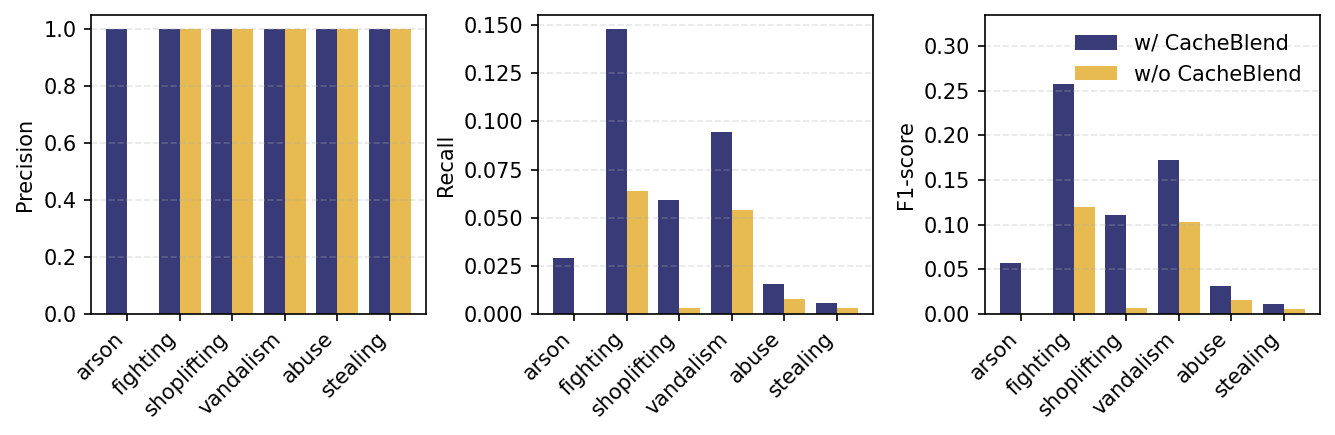

In [219]:
with_cacheblend_dir = "/root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs"
without_cacheblend_dir = "/root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs_baselines"
win_sizes = [120]
stride_sizes = [20]
fps = 1.0
categorys = ["arson", "fighting", "shoplifting", "vandalism", "abuse", "stealing"]
parse_accuracy_log(with_cacheblend_dir, without_cacheblend_dir, win_sizes, stride_sizes, fps, categorys)

methods = ["w_cacheblend", "without_cacheblend"] 
method_labels = ["w/ CacheBlend", "w/o CacheBlend"]   
for win_size in win_sizes:
    for stride_size in stride_sizes:
        plot_metrics_bar_chart(categorys, methods, method_labels, f"../csv/win{win_size}_stride{stride_size}_accuracy_results.csv", f"../pdfs/win{win_size}_stride{stride_size}_accuracy_metrics_bar_chart.pdf")

In [214]:
def load_time_from_log(methods, log_dirs, categorys, win_size, stride_size):
    """Load time from CSV logs under multiple directories and merge into a result CSV."""
    all_rows = []

    for method, log_dir in zip(methods, log_dirs):
        if not os.path.isdir(log_dir):
            print(f"[WARN] Log dir not found, skip: {log_dir}")
            continue

        for category in categorys:
            time_file = os.path.join(
                log_dir,
                f"anomaly_win{win_size}s_stride{stride_size}pct_fps1.0",
                category,
                f"request_times_win{win_size}_stride{stride_size/100}.csv",
            )
            print(f"Processing {time_file}")
            if not os.path.isfile(time_file):
                print(f"[WARN] Time file not found, skip: {time_file}")
                continue

            df_time = pd.read_csv(time_file)
            # delete the first row if it contains warm-up time
            df_time = df_time.iloc[1:]
            for _, row in df_time.iterrows():
                video_name = os.path.splitext(os.path.basename(row["video_path"]))[0]
                all_rows.append({
                    "video_name": video_name,
                    "time_seconds": row["duration_seconds"],
                    "category": category,
                    "method": method,
                    "win_size": win_size,
                    "stride_size": stride_size,
                })

    if not all_rows:
        print("[WARN] No time records loaded.")
        return pd.DataFrame()

    df = pd.DataFrame(all_rows)
    df.sort_values(by=["method", "category", "video_name"], inplace=True)

    out_csv = f"../csv/win{win_size}_stride{stride_size}_time_results.csv"
    if os.path.exists(out_csv):
        df_existing = pd.read_csv(out_csv)
        df = pd.concat([df_existing, df], axis=0, ignore_index=True)

    # Remove duplicates and average time_seconds for the same (video, method, category, win/stride)
    df = (
        df.groupby(
            ["video_name", "method", "category", "win_size", "stride_size"],
            as_index=False
        )["time_seconds"].mean()
    )

    # Pivot: one column per method, values = time_seconds
    df = df.pivot_table(
        index=["video_name", "category", "win_size", "stride_size"],
        columns="method",
        values="time_seconds",
        aggfunc="first"
    ).reset_index()
    df.columns.name = None  # clean column index name

    # Optional: rename method columns if they exist
    rename_map = {}
    if "with_cacheblend" in df.columns:
        rename_map["with_cacheblend"] = "w_cacheblend"
    if "without_cacheblend" in df.columns:
        rename_map["without_cacheblend"] = "without_cacheblend"
    df.rename(columns=rename_map, inplace=True)
    # delete the video_name column
    df.drop(columns=["video_name"], inplace=True)
    # 相同 category, win_size, stride_size 的行合并
    df = df.groupby(["category", "win_size", "stride_size"], as_index=False).mean()
    # 添加一行 ratio列表示 w_cacheblend 相对于 without_cacheblend 的时间reduction ratio
    if "w_cacheblend" in df.columns and "without_cacheblend" in df.columns:
        df["time_reduction_ratio"] = (df["without_cacheblend"] - df["w_cacheblend"]) / df["without_cacheblend"]
    df.to_csv(out_csv, index=False)
    print(f"Loaded and saved {len(df)} records to {out_csv}")
    return df

In [215]:
def plot_latency_bar_chart(categorys, methods, method_labels, csv_file, output_file):
    assert len(methods) == len(method_labels), "methods and method_labels must have same length"
    method_to_label = dict(zip(methods, method_labels))

    df = pd.read_csv(csv_file)

    x = np.arange(len(categorys))
    width = 0.8 / len(methods)  # total width ~0.8, split by methods

    fig, ax = plt.subplots(figsize=(5, 3), dpi=150)

    for j, method in enumerate(methods):
        df_subset = df[["category", method]].set_index("category").reindex(categorys)
        y = df_subset[method].values
        offsets = (j - (len(methods) - 1) / 2) * width
        label = method_to_label[method]
        ax.bar(x + offsets, y, width, label=label, color=plt.cm.tab20b(j/len(methods)))

    # 加一条折线图表示 time_reduction_ratio
    if "time_reduction_ratio" in df.columns:
        df_ratio = df[["category", "time_reduction_ratio"]].set_index("category").reindex(categorys)
        y_ratio = df_ratio["time_reduction_ratio"].values
        ax2 = ax.twinx()
        ax2.plot(x, y_ratio*100, color="red", marker="o", label="Reduction Ratio")
        ax2.set_ylabel("Reduction Ratio (%)", color="red")
        ax2.set_ylim(-30, 50)
        ax2.grid(axis="y", linestyle="--", alpha=0.3)
        ax2.legend(bbox_to_anchor=(0.5, 1.0),frameon=False, borderaxespad=0.)
        for i, v in enumerate(y_ratio):
            ax2.text(x[i], v*100 + 2, f"{v*100:.2f}%", color="red", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_ylim(0, 4.0)
    ax.set_xticklabels(categorys, rotation=45, ha="right")
    ax.set_ylabel("Avg. Latency (s)")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    # 设置 legend 紧凑一些
    ax.legend(loc="upper right", bbox_to_anchor=(1.0, 1.0), borderaxespad=0., frameon=False)
    # fig.suptitle("Precision / Recall / F1-score by Method and Category")
    fig.tight_layout()
    plt.savefig(output_file, bbox_inches="tight")
    plt.show()

Processing /root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/anomaly_win120s_stride20pct_fps1.0/arson/request_times_win120_stride0.2.csv
Processing /root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/anomaly_win120s_stride20pct_fps1.0/fighting/request_times_win120_stride0.2.csv
Processing /root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/anomaly_win120s_stride20pct_fps1.0/shooting/request_times_win120_stride0.2.csv
Processing /root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/anomaly_win120s_stride20pct_fps1.0/shoplifting/request_times_win120_stride0.2.csv
Processing /root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/anomaly_win120s_stride20pct_fps1.0/abuse/request_times_win120_stride0.2.csv
Processing /root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/anomaly_win120s_stride20pct_fps1.0/stealing/request_times_win120_stride0.2.csv
Process

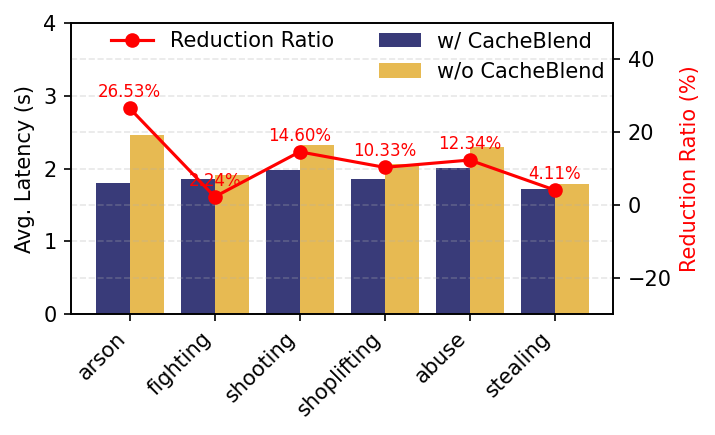

In [216]:
categorys = ["arson", "fighting", "shooting", "shoplifting", "abuse", "stealing"]
with_cacheblend_dir = "/root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs"
without_cacheblend_dir = "/root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs_baselines"
win_size = 120
stride_size = 20
methods = ["w_cacheblend", "without_cacheblend"]
dirs = [with_cacheblend_dir, without_cacheblend_dir]
load_time_from_log(methods, dirs, categorys, win_size, stride_size)

plot_latency_bar_chart(
    categorys,
    methods,
    method_labels,
    f"../csv/win{win_size}_stride{stride_size}_time_results.csv",
    f"../pdfs/win{win_size}_stride{stride_size}_latency_bar_chart.pdf"
)